In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/orange_dataset"

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import zipfile
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

###**Check Folder Structure and Count Images**

In [ ]:
import os
import zipfile

dataset_path = "/content/drive/MyDrive/orange_dataset"
zip_path = "/content/Orange Dataset.zip"

# Create the dataset directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

# Unzip the dataset if the target directory is empty or the zip file exists
if not os.path.exists(os.path.join(dataset_path, "train")) and os.path.exists(zip_path):
    print(f"Unzipping {zip_path} to {dataset_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_path)
    print("Unzipping complete.")

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

# Function to count images per class
def count_images(path):
    if not os.path.exists(path):
        print(f"Error: Directory not found: {path}")
        return

    classes = os.listdir(path)
    if not classes:
        print(f"No classes found in {path}")
        return

    for cls in classes:
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            num_images = len(os.listdir(cls_path))
            print(f"Class: {cls} | Images: {num_images}")
        else:
            print(f"Skipping non-directory item: {cls_path}")

print("Training Dataset:")
count_images(train_path)

print("\nTest Dataset:")
count_images(test_path)

Training Dataset:
Class: blackspot | Images: 184
Class: canker | Images: 179
Class: fresh | Images: 281
Class: grenning | Images: 347

Test Dataset:
Class: blackspot | Images: 22
Class: canker | Images: 22
Class: fresh | Images: 33
Class: grenning | Images: 22


###**Visualize Sample Images Per Class**

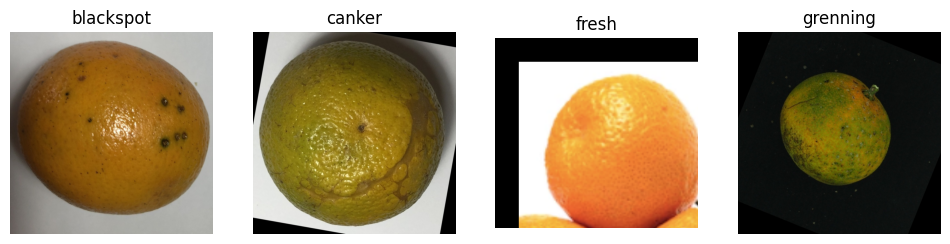

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

def show_sample_images(path, classes, samples_per_class=1):
    plt.figure(figsize=(12,6))
    i = 1
    for cls in classes:
        cls_path = os.path.join(path, cls)
        images = os.listdir(cls_path)
        for _ in range(samples_per_class):
            img_name = random.choice(images)
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, len(classes), i)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
            i += 1
    plt.show()

classes = ["blackspot", "canker", "fresh", "grenning"] # Corrected 'greening' to 'grenning'
show_sample_images(train_path, classes)

###**Check Class Imbalance**

In [ ]:
def class_distribution(path):
    classes = os.listdir(path)
    total = sum([len(os.listdir(os.path.join(path, cls))) for cls in classes])
    print(f"Total images: {total}\n")
    for cls in classes:
        count = len(os.listdir(os.path.join(path, cls)))
        percent = (count/total)*100
        print(f"Class: {cls} | Images: {count} | Percentage: {percent:.2f}%")

print("Training Data Distribution:")
class_distribution(train_path)

print("\nTest Data Distribution:")
class_distribution(test_path)

Training Data Distribution:
Total images: 991

Class: blackspot | Images: 184 | Percentage: 18.57%
Class: canker | Images: 179 | Percentage: 18.06%
Class: fresh | Images: 281 | Percentage: 28.36%
Class: grenning | Images: 347 | Percentage: 35.02%

Test Data Distribution:
Total images: 99

Class: blackspot | Images: 22 | Percentage: 22.22%
Class: canker | Images: 22 | Percentage: 22.22%
Class: fresh | Images: 33 | Percentage: 33.33%
Class: grenning | Images: 22 | Percentage: 22.22%


Step 1.1 — Check Image Sizes

In [ ]:
import numpy as np
import cv2

def check_image_sizes(path, classes):
    sizes = []
    for cls in classes:
        cls_path = os.path.join(path, cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Corrupted image (cannot read): {img_path}")
                    continue
                h, w = img.shape[:2]
                sizes.append((h, w))
            except Exception as e:
                print(f"Error reading {img_path}: {e}")

    sizes = np.array(sizes)
    print(f"Total images checked: {len(sizes)}")
    print(f"Min size: {sizes.min(axis=0)}, Max size: {sizes.max(axis=0)}, Mean size: {sizes.mean(axis=0)}")

check_image_sizes(train_path, classes)

Total images checked: 991
Min size: [138 144], Max size: [800 800], Mean size: [661.72754793 671.18264379]


Step 1.2 — Detect Corrupted Images

In [ ]:
# Example to remove corrupted images
# for img_path in corrupted_images_list:
#     os.remove(img_path)

Step 2.1 — Data Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

Create Training Data Generator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,   # normalize pixels

    rotation_range=20,   # random rotations
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.2,
    horizontal_flip=True
)

Test Data Generator

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

Load Training Dataset

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 991 images belonging to 4 classes.


Load Test Dataset

In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 99 images belonging to 4 classes.


####Step 4 — Classical Computer Vision Pipeline

Step 4.1 — Load Images and Convert to Feature Dataset

In [ ]:
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
import numpy as np
import cv2

X = []
y = []

IMG_SIZE = 224

Feature Extraction Function

In [ ]:
def extract_features(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # ---- COLOR FEATURES ----
    mean_color = img.mean(axis=(0,1))   # RGB mean

    # ---- TEXTURE FEATURES (LBP) ----
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")

    (hist, _) = np.histogram(lbp.ravel(),
                             bins=np.arange(0, 11),
                             range=(0, 10))

    hist = hist.astype("float")
    hist /= hist.sum()

    features = np.hstack([mean_color, hist])

    return features

Step 4.2 — Create Feature Dataset

In [ ]:
classes = ["blackspot", "canker", "fresh", "grenning"]

for label, cls in enumerate(classes):

    cls_path = os.path.join(train_path, cls)

    for img_name in os.listdir(cls_path):

        img_path = os.path.join(cls_path, img_name)

        features = extract_features(img_path)

        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

Feature shape: (991, 13)


Step 4.3 — Train Machine Learning Model (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

Train/Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train SVM

In [ ]:
svm_model = SVC(kernel='rbf', probability=True)

svm_model.fit(X_train, y_train)

pred = svm_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, pred))

print(classification_report(y_val, pred))

Accuracy: 0.8341708542713567
              precision    recall  f1-score   support

           0       0.53      0.81      0.64        32
           1       0.75      0.32      0.44        38
           2       0.93      0.98      0.96        57
           3       0.97      1.00      0.99        72

    accuracy                           0.83       199
   macro avg       0.80      0.78      0.76       199
weighted avg       0.85      0.83      0.82       199



Step 5 — Confusion Matrix

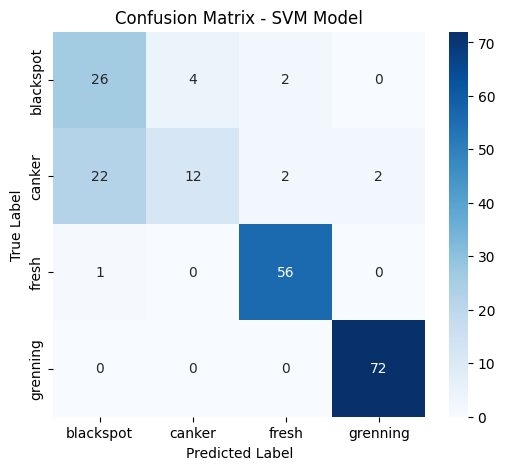

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Model")

plt.show()

####**Approach 2 — Deep Learning CNN Model**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

# Create CNN model
cnn_model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
EPOCHS = 10

history = cnn_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.9142 - loss: 0.2522 - val_accuracy: 0.9192 - val_loss: 0.2655
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9758 - loss: 0.0555 - val_accuracy: 0.9394 - val_loss: 0.1487
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9778 - loss: 0.0572 - val_accuracy: 0.9495 - val_loss: 0.1349
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9849 - loss: 0.0418 - val_accuracy: 0.9293 - val_loss: 0.1531
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9879 - loss: 0.0288 - val_accuracy: 0.9293 - val_loss: 0.1584
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9788 - loss: 0.0476 - val_accuracy: 0.9293 - val_loss: 0.1892
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9839 - loss: 0.0446 - val_accuracy: 0.9495 - val_loss: 0.1396
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9899

Plot Training Curves

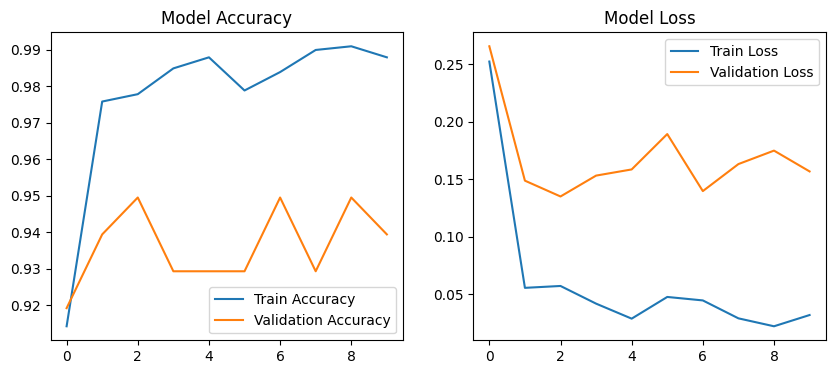

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")

plt.show()

CNN Evaluation Metrics

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_probs = cnn_model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes, target_names=classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
              precision    recall  f1-score   support

   blackspot       0.86      0.86      0.86        22
      canker       0.86      0.86      0.86        22
       fresh       1.00      1.00      1.00        33
    grenning       1.00      1.00      1.00        22

    accuracy                           0.94        99
   macro avg       0.93      0.93      0.93        99
weighted avg       0.94      0.94      0.94        99



confusion matrix

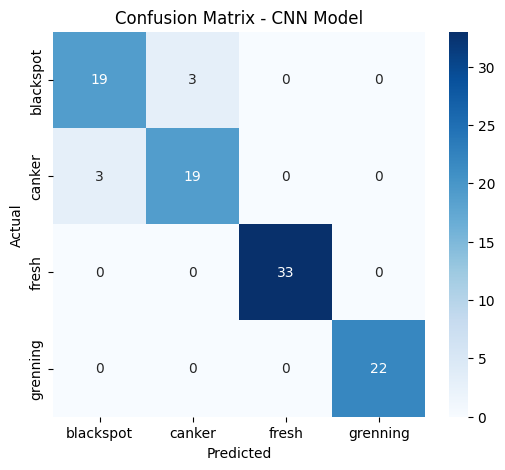

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN Model")

plt.show()

Spoilage Percentage Estimation


In [ ]:
def predict_spoilage(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Error: Image not found or wrong path")
        return

    img = cv2.resize(img,(224,224))
    img = img/255.0
    img = np.expand_dims(img,axis=0)

    pred = cnn_model.predict(img)
    class_idx = np.argmax(pred)

    class_name = classes[class_idx]

    spoilage_dict = {
        "fresh":0,
        "blackspot":50,
        "canker":70,
        "grenning":90
    }

    spoilage = spoilage_dict[class_name]

    print("Predicted Class:",class_name)
    print("Estimated Spoilage:",spoilage,"%")

In [ ]:
import os

sample_folder = "/content/drive/MyDrive/orange_dataset/test/blackspot"

print(os.listdir(sample_folder)[:5])

['b (1).jpg', 'b (10).jpg', 'b (11).jpg', 'b (12).jpg', 'b (13).jpg']


Blackspot

In [ ]:

predict_spoilage("/content/drive/MyDrive/orange_dataset/test/blackspot/b (1).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted Class: blackspot
Estimated Spoilage: 50 %


Canker

In [ ]:
os.listdir("/content/drive/MyDrive/orange_dataset/test/canker")[:5]

['c (1).jpg', 'c (10).jpg', 'c (11).jpg', 'c (12).jpg', 'c (13).jpg']

In [ ]:
predict_spoilage("/content/drive/MyDrive/orange_dataset/test/canker/c (1).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Class: canker
Estimated Spoilage: 70 %


Fresh

In [ ]:
os.listdir("/content/drive/MyDrive/orange_dataset/test/fresh")[:5]

['f (1).png', 'f (10).png', 'f (11).png', 'f (12).png', 'f (13).png']

In [ ]:
predict_spoilage("/content/drive/MyDrive/orange_dataset/test/fresh/f (1).png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Class: fresh
Estimated Spoilage: 0 %


Greening

In [ ]:
os.listdir("/content/drive/MyDrive/orange_dataset/test/grenning")[:5]

['g (1).jpg', 'g (10).jpg', 'g (11).jpg', 'g (12).jpg', 'g (13).jpg']

In [ ]:
predict_spoilage("/content/drive/MyDrive/orange_dataset/test/grenning/g (1).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Predicted Class: grenning
Estimated Spoilage: 90 %
